In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,            # Turn off external LaTeX compiler
    "font.family": "serif",          # Use serif fonts
    "mathtext.fontset": "cm",        # Use Computer Modern for math/LaTeX text
    "font.serif": ["cmr10", "Computer Modern Roman"], # Try cmr10 first, fallback to CM Roman
    "axes.formatter.use_mathtext": True
})

df = pd.read_csv("mgb_HELMET8_output_for_zach.csv")
df

,ptid_idx,hour,true_scans,interpolated_mls_class,last_known_mls_class,proba_0,proba_1,proba_2,proba_3
0,1,0,0,0,NaN,0.445908,0.318474,0.118668,0.116950
1,1,1,1,0,0.0,0.455688,0.282771,0.137140,0.124401
2,1,2,0,0,0.0,0.455688,0.282771,0.137140,0.124401
3,1,3,0,0,0.0,0.455688,0.282771,0.137140,0.124401
4,1,4,0,0,0.0,0.455688,0.282771,0.137140,0.124401
...,...,...,...,...,...,...,...,...,...
138476,674,332,0,1,1.0,0.144472,0.489204,0.258802,0.107521
138477,674,333,0,1,1.0,0.144472,0.489204,0.258802,0.107521
138478,674,334,0,1,1.0,0.143071,0.479518,0.274290,0.103121
138479,674,335,0,1,1.0,0.143071,0.479518,0.274290,0.103121


In [3]:
# Get the index ranges of the various patients

patientId = 1
indexList2 = []
for i in range(138481):
    if patientId == df.iat[i,0]:
        continue
    else:
        patientId = df.iat[i,0]
        indexList2.append(i)

In [4]:
# Determines whether a patient received a scan and, if so, finds the time index of the first scan and patient class

def goToFirstScan(patientMatrix):
    scanned = False
    timeIndex = 0
    patClass = 0
    lenStay = len(patientMatrix[:,0])
    for i in range(lenStay):
        if patientMatrix[i,2] == 1:
            timeIndex = i
            scanned = True
            # Check
            if math.isnan(patientMatrix[i,4]):
                print('Error')
            patClass = patientMatrix[i,4]+1
            break
    return scanned, timeIndex, patClass

In [5]:
# Get the patient data

patientData = []

# Assign Features
scannedPatient = 0
for i in range(674):
    if i == 0:
        patientMatrix = df.iloc[i:indexList2[i], 0:].to_numpy() # Selects subset of the dataframe
        wasScanned, firstScanTime, patClass = goToFirstScan(patientMatrix)
        # Check we have at least 8 hours of data after the first scan
        if wasScanned and len(patientMatrix[firstScanTime+1:,0]) >= 3:
            patientData.append(patientMatrix[firstScanTime:,:])
            scannedPatient += 1
        else:
            print(f'Skipped Patient {i+1}')
    elif i < 673:
        patientMatrix = df.iloc[indexList2[i-1]:indexList2[i], 0:].to_numpy() # Selects subset of the dataframe
        wasScanned, firstScanTime, patClass = goToFirstScan(patientMatrix)
        # Check we have at least 8 hours of data after the first scan
        if wasScanned and len(patientMatrix[firstScanTime+1:,0]) >= 3:
            patientData.append(patientMatrix[firstScanTime:,:])
            scannedPatient += 1
        else:
            print(f'Skipped Patient {i+1}')
    else:
        patientMatrix = df.iloc[indexList2[-1]:, 0:].to_numpy() # Selects subset of the dataframe
        wasScanned, firstScanTime, patClass = goToFirstScan(patientMatrix)
        # Check we have at least 3 hours of data after the first scan
        if wasScanned and len(patientMatrix[firstScanTime+1:,0]) >= 3:
            patientData.append(patientMatrix[firstScanTime:,:])
            scannedPatient += 1
        else:
            print(f'Skipped Patient {i+1}')

Skipped Patient 240
Skipped Patient 253
Skipped Patient 256
Skipped Patient 293
Skipped Patient 364
Skipped Patient 570


In [6]:
# Helper methods

# Return class + 1
def mode(probs):
    return np.argmax(probs) + 1

# Measure the uncertainty of the prediction
def predictive_entropy(probs, eps=1e-8):
    probs = np.clip(probs, eps, 1.0)
    H = -np.sum(probs * np.log(probs))
    return H

# Divergence from previous
def kl_divergence(p, q, eps=1e-8):
    """
    Computes D_KL(p || q) for discrete distributions.

    p, q: 1D numpy arrays summing to 1
    eps: numerical stability constant
    """
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)

    return np.sum(p * np.log(p / q))


def MSE(y_pred, y_true):
    return np.sum((y_pred-y_true)**2)

# Create the feature vector
def addFeatures2(time, patientProbs, prevPatientProbs, lastKnownState):
    mHat = mode(patientProbs)
    mHatLast = mode(prevPatientProbs)
    uncert = predictive_entropy(patientProbs)
    prevUncert = predictive_entropy(prevPatientProbs)
    diverge = kl_divergence(patientProbs, prevPatientProbs)
    output = np.zeros(15, dtype='float')
    output[0] = mHat
    output[1] = mHatLast
    output[2] = uncert
    output[3] = prevUncert
    output[4] = diverge
    output[5] = time
    output[6] = lastKnownState
    # Add the probability features
    for i in range(4):
        output[i+7] = patientProbs[i]
    # Add the previous probabilities
    for i in range(4):
        output[i+11] = prevPatientProbs[i]
    return output

In [7]:
# Get the features

dataFeatures = []

for i in range(len(patientData)):
    patFeatures = []
    patient = patientData[i]
    # Minus one because we keep an extra row for the previous probabilities
    numValues = len(patient[:,0])-1
    # Go through the entire length of stay
    for j in range(numValues):
        lastKnownState = patient[j,4]+1
        prevProbs = patient[j,5:]
        probs = patient[j+1, 5:]
        currentTime = patient[j+1, 1]
        featureVec = addFeatures2(currentTime, probs, prevProbs, lastKnownState)
        patFeatures.append(featureVec)
    dataFeatures.append(np.array(patFeatures))

print(len(dataFeatures))

668


In [8]:
# Construct patient objects

class Patient2:
    def __init__(self, patient_id, features, patient_scans, T):
        """
        Parameters
        ----------
        patient_id : int or str
            Unique patient identifier
        patient_rewards : list of length T
        reward for scanning at each time point
        features : np.array
        features for each time point
        patient_scans : np.array
        Identifies whether or not a patient was scanned at each time point
        T : int
            Total length of stay (hours)
        """
        self.id = patient_id
        self.features = features
        self.T = T
        self.scans = patient_scans

    def get_id(self):
        return self.id
    
    def get_context(self, t):
        """Return feature vector at decision time t"""
        # Find index corresponding to current hour
        context = self.features[t,:]
        return context

    def get_scans(self, t):
        """Return clinician scans for (t,t+3)"""
        scans = self.scans[t:t+3]
        return scans

In [9]:
dfV = pd.read_csv("HELMET8_scan_rewards_1.csv")

In [10]:
patientId = 1
indexList = []
for i in range(136721):
    if patientId == dfV.iat[i,0]:
        continue
    else:
        patientId = dfV.iat[i,0]
        indexList.append(i)

patientIDs = np.zeros(668)

for i in range(667):
    if i == 0:
        patientIDs[i] = dfV.iloc[0,0]
    else:
        patientIDs[i] = dfV.iloc[indexList[i-1],0]

patientIDs[-1] = dfV.iloc[indexList[-1], 0]

In [11]:
# Create an array of patients
patientArray = np.zeros(668, dtype='object')

for i in range(len(patientArray)):
    patientFeatures = dataFeatures[i]
    patient = patientData[i]
    patientID = patientIDs[i]
    # create patient
    patient = Patient2(
    patient_id=patientID,
    features=patientFeatures,
    patient_scans=patient[:,2],
    T=len(patient[:,2])
    )
    patientArray[i] = patient

In [12]:
# Generated by Google Gemini

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 1. Aggregate X (Features) and y (Targets)
# ----------------------------------------
X_list = []
y_list = []

# Iterate through each patient to align features with targets
for i in range(len(patientData)):
    # dataFeatures[i] contains the features calculated in Cell [6]
    # corresponding to time steps t=1 to T (skipping t=0)
    X_pat = dataFeatures[i]
    
    # patientData[i] is the raw matrix. Column 2 is 'true_scans'.
    # We slice [1:, 2] to match the indices used in dataFeatures (starting at j+1)
    y_pat = patientData[i][1:, 2]
    
    # Safety check to ensure dimensions match
    if X_pat.shape[0] != y_pat.shape[0]:
        print(f"Dimension mismatch for patient {i}: X={X_pat.shape}, y={y_pat.shape}")
        continue
        
    X_list.append(X_pat)
    y_list.append(y_pat)

# Stack into single matrices
X_train = np.vstack(X_list)
y_train = np.concatenate(y_list)

print(f"Training Data Shape: X={X_train.shape}, y={y_train.shape}")
print(f"Scan Rate in Data: {y_train.mean():.4f}")

# 2. Preprocessing & Training
# ---------------------------
# Scale features (important for Logistic Regression convergence and interpretation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit Logistic Regression
# We use standard weights here to get calibrated probabilities for IPW
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 3. Output Propensity Scores
# ---------------------------
# These are the P(Scan=1 | X)
propensity_scores = log_reg.predict_proba(X_train_scaled)[:, 1]

# Optional: Add back to a dataframe for inspection
df_propensity = pd.DataFrame({
    'true_scan': y_train,
    'propensity_score': propensity_scores
})

print("\nModel Coefficients (Top Influencers):")
feature_names = [
    'mHat', 'mHatLast', 'uncert', 'prevUncert', 'diverge', 'time', 'lastKnownState',
    'curr_prob0', 'curr_prob1', 'curr_prob2', 'curr_prob3',
    'prev_prob0', 'prev_prob1', 'prev_prob2', 'prev_prob3'
]
coefs = pd.Series(log_reg.coef_[0], index=feature_names).sort_values(ascending=False)
print(coefs)

# Histogram of propensity scores
print("\nPropensity Score Stats:")
print(df_propensity['propensity_score'].describe())

Training Data Shape: X=(136721, 15), y=(136721,)
Scan Rate in Data: 0.0174

Model Coefficients (Top Influencers):
diverge           5.077778
curr_prob1        3.946435
prev_prob2        2.574790
prevUncert        0.885468
prev_prob3        0.644118
curr_prob0        0.626971
mHat              0.223694
curr_prob3       -0.130969
lastKnownState   -0.393282
prev_prob0       -1.378404
mHatLast         -1.510737
time             -1.573623
uncert           -1.669417
curr_prob2       -2.378165
prev_prob1       -4.063446
dtype: float64

Propensity Score Stats:
count    136721.000000
mean          0.017417
std           0.084016
min           0.000020
25%           0.001333
50%           0.005525
75%           0.015466
max           1.000000
Name: propensity_score, dtype: float64


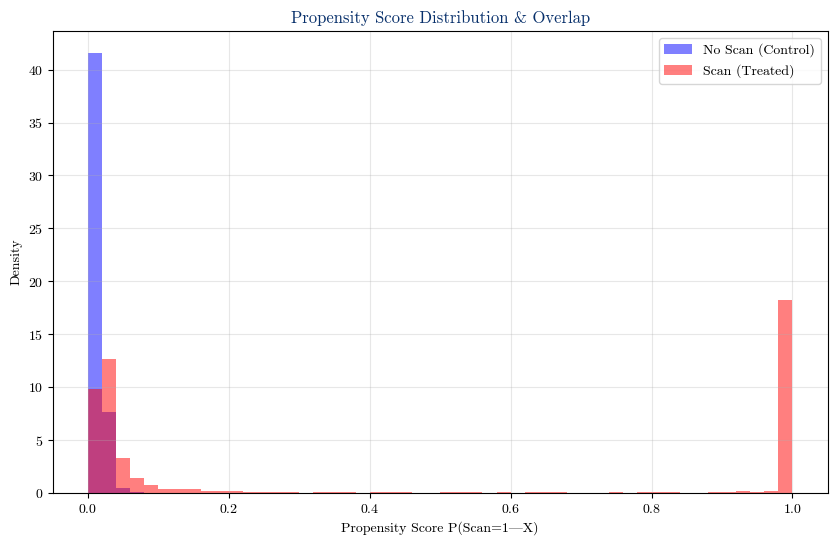

Control (No Scan) Range: [0.0000, 1.0000]
Treated (Scan) Range:    [0.0002, 1.0000]
Region of Common Support: [0.0002, 1.0000]


In [17]:
# Generated by Google Gemini

# Create the plot
plt.figure(figsize=(10, 6))

# Plot histogram for No Scan (Control)
plt.hist(df_propensity[df_propensity['true_scan'] == 0]['propensity_score'], 
         bins=50, alpha=0.5, label='No Scan (Control)', density=True, color='blue')

# Plot histogram for Scan (Treated)
plt.hist(df_propensity[df_propensity['true_scan'] == 1]['propensity_score'], 
         bins=50, alpha=0.5, label='Scan (Treated)', density=True, color='red')

plt.xlabel('Propensity Score P(Scan=1|X)')
plt.ylabel('Density')
plt.title('Propensity Score Distribution & Overlap', color='#08306b')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate specific overlap statistics
control_scores = df_propensity[df_propensity['true_scan'] == 0]['propensity_score']
treated_scores = df_propensity[df_propensity['true_scan'] == 1]['propensity_score']

print(f"Control (No Scan) Range: [{control_scores.min():.4f}, {control_scores.max():.4f}]")
print(f"Treated (Scan) Range:    [{treated_scores.min():.4f}, {treated_scores.max():.4f}]")

# Identify region of common support
min_common = max(control_scores.min(), treated_scores.min())
max_common = min(control_scores.max(), treated_scores.max())
print(f"Region of Common Support: [{min_common:.4f}, {max_common:.4f}]")

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cb/lpypgwkj33jgl1w1136v64yh0000gn/T/ipykernel_15278/2920419930.py:33: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Propensity Score $P(\mathrm{Scan}=1|X)$')


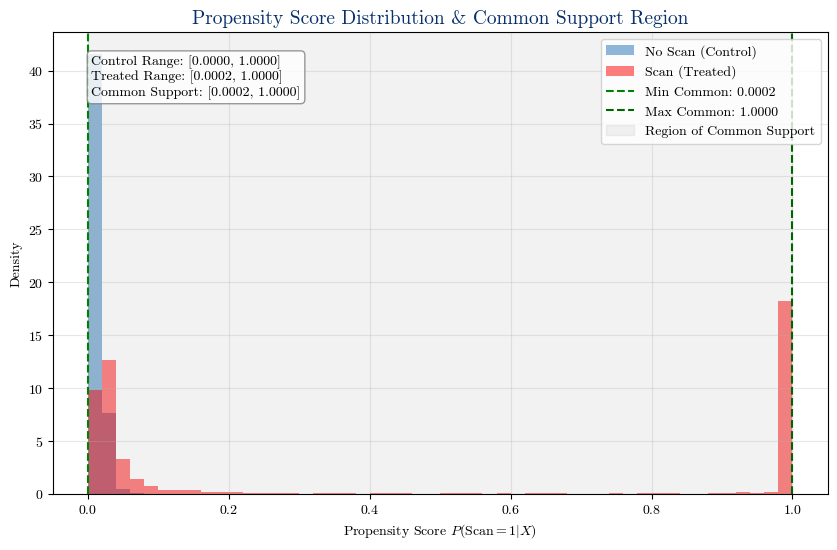

In [19]:
# Generated by Google Gemini and modified by me

import matplotlib.pyplot as plt

# 1. Calculate the region of common support (if not already done)
control_scores = df_propensity[df_propensity['true_scan'] == 0]['propensity_score']
treated_scores = df_propensity[df_propensity['true_scan'] == 1]['propensity_score']

min_common = max(control_scores.min(), treated_scores.min())
max_common = min(control_scores.max(), treated_scores.max())

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot histograms
plt.hist(control_scores, bins=50, alpha=0.5, label='No Scan (Control)', density=True, color='#2171b5')
plt.hist(treated_scores, bins=50, alpha=0.5, label='Scan (Treated)', density=True, color='red')

# 3. Add vertical lines and shaded region
plt.axvline(min_common, color='green', linestyle='--', linewidth=1.5, label=f'Min Common: {min_common:.4f}')
plt.axvline(max_common, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Max Common: {max_common:.4f}')
plt.axvspan(min_common, max_common, color='gray', alpha=0.1, label='Region of Common Support')

# 4. Add summary text box
textstr = '\n'.join((
    f'Control Range: [{control_scores.min():.4f}, {control_scores.max():.4f}]',
    f'Treated Range: [{treated_scores.min():.4f}, {treated_scores.max():.4f}]',
    f'Common Support: [{min_common:.4f}, {max_common:.4f}]'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=props)

# Formatting
plt.xlabel('Propensity Score $P(\mathrm{Scan}=1|X)$')
plt.ylabel('Density')
plt.title('Propensity Score Distribution & Common Support Region', color='#08306b', fontsize=14)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)

# 5. Save the figure (added this line)
plt.savefig('propensity_common_support.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:
print(coefs)

diverge           5.077778
curr_prob1        3.946435
prev_prob2        2.574790
prevUncert        0.885468
prev_prob3        0.644118
curr_prob0        0.626971
mHat              0.223694
curr_prob3       -0.130969
lastKnownState   -0.393282
prev_prob0       -1.378404
mHatLast         -1.510737
time             -1.573623
uncert           -1.669417
curr_prob2       -2.378165
prev_prob1       -4.063446
dtype: float64


In [15]:
# Generated by Google Gemini

# 1. Calculate raw IPW without propensity clipping (to see the true variance)
# Weight = 1/p for scans, 1/(1-p) for no-scans
df_propensity['ipw_raw'] = np.where(
    df_propensity['true_scan'] == 1, 
    1 / df_propensity['propensity_score'], 
    1 / (1 - df_propensity['propensity_score'])
)

# 2. Define the trimming percentile (e.g., 99th percentile)
trim_threshold = df_propensity['ipw_raw'].quantile(0.99)
print(f"Trimming IPW weights at 99th percentile: {trim_threshold:.2f}")

# 3. Apply the trim (cap the weights)
df_propensity['ipw'] = df_propensity['ipw_raw'].clip(upper=trim_threshold)

# 4. Check the new distribution
print("\nNew Trimmed IPW Stats:")
print(df_propensity['ipw'].describe())

Trimming IPW weights at 99th percentile: 9.01

New Trimmed IPW Stats:
count    136721.000000
mean          1.094501
std           0.808050
min           1.000000
25%           1.001285
50%           1.005414
75%           1.015477
max           9.008649
Name: ipw, dtype: float64


In [16]:
# Generated by Google Gemini

# 1. Re-align IDs and Hours (matching the [1:] slice used in training)
ptid_list = []
hour_list = []

for i in range(len(patientData)):
    # Column 0 is ptid_idx, Column 1 is hour
    ptid_list.append(patientData[i][1:, 0])
    hour_list.append(patientData[i][1:, 1])

# 2. Add them to your existing propensity dataframe
df_propensity['ptid_idx'] = np.concatenate(ptid_list)
df_propensity['hour'] = np.concatenate(hour_list)

# 3. Reorder columns for better readability and save
cols = ['ptid_idx', 'hour', 'true_scan', 'propensity_score', 'ipw']
df_propensity[cols].to_csv('patient_ipw_weights.csv', index=False)

print("Successfully saved weights to 'patient_ipw_weights.csv'")

Successfully saved weights to 'patient_ipw_weights.csv'
